In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

2026-05-07 15:19:16.374388: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778167156.601285      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778167156.664230      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778167157.167991      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778167157.168034      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778167157.168036      57 computation_placer.cc:177] computation placer alr

In [2]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── CONFIG ──────────────────────────────────────────────────────────────────
VOCAB_SIZE    = 10000
MAX_LENGTH    = 200
EMBEDDING_DIM = 128
BATCH_SIZE    = 64
EPOCHS        = 20
FILTER_SIZES  = [2, 3, 4, 5]
NUM_FILTERS   = 128
DROPOUT_RATE  = 0.5
DATA_PATH     = '/kaggle/input/datasets/cjpuertollano/clean-withoutrating/CLEANED(without Rating)_dataset (1).csv'

In [3]:
# ── 1. LOAD DATA ─────────────────────────────────────────────────────────────
try:
    df = pd.read_csv(DATA_PATH)

    # Normalize column names
    df.columns = df.columns.str.lower().str.strip()

    # Validate expected columns
    assert {'label', 'review'}.issubset(df.columns), \
        f"Missing columns! Found: {df.columns.tolist()}"

except FileNotFoundError:
    print("File not found — using synthetic demo data.")
    df = pd.DataFrame({
        'label':  np.random.choice(['OR', 'CG'], 5000),
        'review': [f"Sample review text number {i}" for i in range(5000)]
    })

# Drop nulls & reset index
df = df[['label', 'review']].dropna().reset_index(drop=True)

print(f"Loaded       : {len(df)} samples")
print(f"Label counts : {df['label'].value_counts().to_dict()}")
print(f"Sample review: {df['review'].iloc[0][:80]}...")

Loaded       : 40411 samples
Label counts : {'OR': 20215, 'CG': 20196}
Sample review: love this  well made sturdy and very comfortable  i love itvery pretty...


In [4]:
# ── 2. TOKENIZATION ──────────────────────────────────────────────────────────
texts  = df['review'].astype(str).values
labels = df['label'].values

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
print(f"\nVocab size   : {len(tokenizer.word_index)}")
print(f"Padded shape : {X.shape}")


Vocab size   : 48455
Padded shape : (40411, 200)


In [5]:
# ── 3. LABEL ENCODING ────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(labels)
print(f"Classes      : {dict(zip(le.classes_, le.transform(le.classes_)))}")
# Alphabetical order: CG=0, OR=1

Classes      : {'CG': np.int64(0), 'OR': np.int64(1)}


In [6]:
# ── 4. TRAIN / VAL / TEST SPLIT ──────────────────────────────────────────────
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
X_val,   X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
print(f"\nSplit → Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


Split → Train: 32328 | Val: 4041 | Test: 4042


In [7]:
# ── 5. MULTI-CHANNEL CNN MODEL ───────────────────────────────────────────────
#
#  Pipeline:
#  Input
#    ├─ Channel 1: Static (frozen) Embedding → Conv1D × filter_sizes → GlobalMaxPool
#    └─ Channel 2: Trainable Embedding       → Conv1D × filter_sizes → GlobalMaxPool
#  Concatenate all pooled outputs
#  Dense(256) → Dense(128) → Sigmoid output
#
def build_multichannel_cnn():
    inp = layers.Input(shape=(MAX_LENGTH,), name="input")

    # ── Channel 1: Static / Frozen Embedding ─────────────────────────────────
    static_emb = layers.Embedding(
        VOCAB_SIZE, EMBEDDING_DIM,
        trainable=False,
        name="static_embedding"
    )(inp)
    static_emb = layers.SpatialDropout1D(0.2)(static_emb)

    # ── Channel 2: Trainable Embedding ───────────────────────────────────────
    trainable_emb = layers.Embedding(
        VOCAB_SIZE, EMBEDDING_DIM,
        trainable=True,
        name="trainable_embedding"
    )(inp)
    trainable_emb = layers.SpatialDropout1D(0.2)(trainable_emb)

    # ── Parallel Conv1D layers per channel ───────────────────────────────────
    pooled = []
    for emb, tag in [(static_emb, "static"), (trainable_emb, "trainable")]:
        for fs in FILTER_SIZES:
            x = layers.Conv1D(NUM_FILTERS, fs, activation='relu',
                              padding='same', name=f"conv_{tag}_fs{fs}")(emb)
            x = layers.BatchNormalization()(x)
            x = layers.GlobalMaxPooling1D(name=f"pool_{tag}_fs{fs}")(x)
            pooled.append(x)

    # ── Concatenate all outputs ───────────────────────────────────────────────
    merged = layers.concatenate(pooled, name="concat")

    # ── Dense → Output ────────────────────────────────────────────────────────
    x = layers.Dense(256, activation='relu')(merged)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid', name="output")(x)

    return models.Model(inputs=inp, outputs=out)

model = build_multichannel_cnn()
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

I0000 00:00:1778167188.174292      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778167188.180087      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 200)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_embedding    │ (None, 200, 128)  │  1,280,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trainable_embedding │ (None, 200, 128)  │  1,280,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 200, 128)  │          0 │ static_embedding… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 200, 128)  │          0 │ trainable_embedd… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_static_fs2     │ (None, 200, 128)  │     32,896 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_static_fs3     │ (None, 200, 128)  │     49,280 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_static_fs4     │ (None, 200, 128)  │     65,664 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_static_fs5     │ (None, 200, 128)  │     82,048 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_trainable_fs2  │ (None, 200, 128)  │     32,896 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_trainable_fs3  │ (None, 200, 128)  │     49,280 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_trainable_fs4  │ (None, 200, 128)  │     65,664 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_trainable_fs5  │ (None, 200, 128)  │     82,048 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 200, 128)  │        512 │ conv_static_fs2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 128)  │        512 │ conv_static_fs3[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 128)  │        512 │ conv_static_fs4[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 128)  │        512 │ conv_static_fs5[… │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 3,320,833 (12.67 MB)

 Trainable params: 2,038,017 (7.77 MB)

 Non-trainable params: 1,282,816 (4.89 MB)

In [8]:
# ── 6. CALLBACKS ─────────────────────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
]

In [9]:
# ── 7. TRAIN ─────────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


I0000 00:00:1778167196.472928     129 service.cc:152] XLA service 0x7d94e0006d50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778167196.472961     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778167196.472965     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778167197.826716     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-07 15:20:00.509278: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.31 = (f32[64,128,1,200]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,128,1,200]{3,2,1,0} %bitcast.17855, f32[128,128,1,5]{3,2,1,0} %bitcast.18031, f32[128]{0} %bitcast.22052), window={size=1x5 pad=0_0x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1/conv_static_fs5_1/convoluti

  5/506 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.4881 - loss: 1.0074 - precision: 0.4772 - recall: 0.4590  

I0000 00:00:1778167214.998026     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6594 - loss: 0.7014 - precision: 0.6577 - recall: 0.6467

...

506/506 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8488 - loss: 0.3542 - precision: 0.8498 - recall: 0.8425 - val_accuracy: 0.8728 - val_loss: 0.2791 - val_precision: 0.9671 - val_recall: 0.7719 - learning_rate: 1.0000e-04
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8915 - loss: 0.2635 - precision: 0.8900 - recall: 0.8902 - val_accuracy: 0.8728 - val_loss: 0.2831 - val_precision: 0.9796 - val_recall: 0.7615 - learning_rate: 1.0000e-04
Epoch 4/20
505/506 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9159 - loss: 0.2048 - precision: 0.9138 - recall: 0.9159

506/506 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9159 - loss: 0.2048 - precision: 0.9138 - recall: 0.9159 - val_accuracy: 0.8990 - val_loss: 0.2280 - val_precision: 0.9719 - val_recall: 0.8219 - learning_rate: 1.0000e-04
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9329 - loss: 0.1625 - precision: 0.9293 - recall: 0.9353 - val_accuracy: 0.8916 - val_loss: 0.2410 - val_precision: 0.9737 - val_recall: 0.8050 - learning_rate: 1.0000e-04
Epoch 6/20
505/506 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9473 - loss: 0.1310 - precision: 0.9468 - recall: 0.9464

506/506 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9473 - loss: 0.1310 - precision: 0.9469 - recall: 0.9464 - val_accuracy: 0.9191 - val_loss: 0.1853 - val_precision: 0.9732 - val_recall: 0.8619 - learning_rate: 1.0000e-04
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9610 - loss: 0.1028 - precision: 0.9577 - recall: 0.9636 - val_accuracy: 0.9045 - val_loss: 0.2296 - val_precision: 0.9823 - val_recall: 0.8238 - learning_rate: 1.0000e-04
Epoch 8/20
505/506 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9686 - loss: 0.0814 - precision: 0.9667 - recall: 0.9697

506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9686 - loss: 0.0814 - precision: 0.9667 - recall: 0.9697 - val_accuracy: 0.9379 - val_loss: 0.1598 - val_precision: 0.9663 - val_recall: 0.9075 - learning_rate: 1.0000e-04
Epoch 9/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9764 - loss: 0.0628 - precision: 0.9741 - recall: 0.9783 - val_accuracy: 0.9263 - val_loss: 0.2131 - val_precision: 0.9700 - val_recall: 0.8798 - learning_rate: 1.0000e-04
Epoch 10/20
504/506 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9817 - loss: 0.0504 - precision: 0.9804 - recall: 0.9826
Epoch 10: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.


506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9817 - loss: 0.0504 - precision: 0.9804 - recall: 0.9826 - val_accuracy: 0.9389 - val_loss: 0.1750 - val_precision: 0.9688 - val_recall: 0.9070 - learning_rate: 1.0000e-04
Epoch 11/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9873 - loss: 0.0382 - precision: 0.9859 - recall: 0.9883 - val_accuracy: 0.9213 - val_loss: 0.2347 - val_precision: 0.9776 - val_recall: 0.8624 - learning_rate: 2.0000e-05
Epoch 12/20
504/506 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9887 - loss: 0.0315 - precision: 0.9882 - recall: 0.9890
Epoch 12: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9887 - loss: 0.0315 - precision: 0.9882 - recall: 0.9890 - val_accuracy: 0.9144 - val_loss: 0.2618 - val_precision: 0.9799 - val_recall: 0.8461 - learning_rate: 2.0000e-05
Epoch 13/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9902 - loss: 0.0300 - precision: 0

In [10]:
# ── 8. EVALUATE ──────────────────────────────────────────────────────────────
test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)
f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec + 1e-7)

y_pred = (model.predict(X_test, verbose=0).flatten() > 0.5).astype(int)

print("\n── TEST RESULTS ──────────────────────────────────────────")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall   : {test_rec:.4f}")
print(f"  F1-Score : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


── TEST RESULTS ──────────────────────────────────────────
  Accuracy : 0.9386
  Precision: 0.9728
  Recall   : 0.9026
  F1-Score : 0.9364

Classification Report:
              precision    recall  f1-score   support

          CG       0.91      0.97      0.94      2020
          OR       0.97      0.90      0.94      2022

    accuracy                           0.94      4042
   macro avg       0.94      0.94      0.94      4042
weighted avg       0.94      0.94      0.94      4042



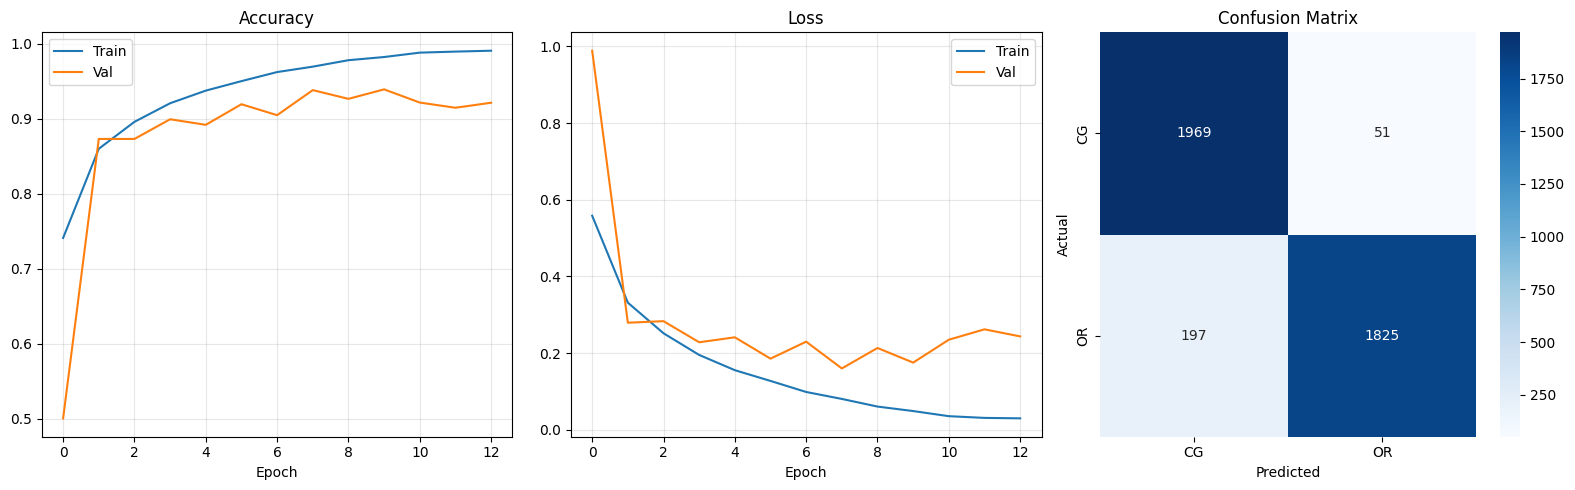

In [11]:
# ── 9. PLOTS ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy');  axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss');      axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── 10. INTERACTIVE INPUT ────────────────────────────────────────────────────
def predict_review(text):
    seq       = tokenizer.texts_to_sequences([text])
    padded    = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
    pred_prob = model.predict(padded, verbose=0)[0][0]

    # LabelEncoder sorts alphabetically: CG=0, OR=1
    class_idx  = 1 if pred_prob > 0.5 else 0
    label      = le.inverse_transform([class_idx])[0]
    confidence = pred_prob if class_idx == 1 else (1 - pred_prob)

    if confidence > 0.90:
        level = "Very High"
    elif confidence > 0.75:
        level = "High"
    else:
        level = "Moderate"

    return {
        'label':      label,
        'confidence': confidence,
        'level':      level,
        'raw_score':  pred_prob
    }

print("\n" + "="*60)
print("             🚀 AI vs. HUMAN REVIEW DETECTOR")
print("="*60)
print("Instructions: Enter a product review below to analyze its origin.")
print("Type 'quit' or 'exit' to stop.")

while True:
    print("\n" + "─"*60)
    user_input = input("📝 ENTER REVIEW: ").strip()

    if user_input.lower() in ['quit', 'exit']:
        print("👋 Goodbye!")
        break

    if len(user_input) < 5:
        print("⚠️  Review is too short for a reliable analysis.")
        continue

    res       = predict_review(user_input)
    color_box = "■" * int(res['confidence'] * 20)
    gray_box  = "□" * (20 - len(color_box))

    print(f"\nRESULT    : {res['label'].upper()}")
    print(f"CONFIDENCE: [{color_box}{gray_box}] {res['confidence']*100:.1f}% ({res['level']})")

    if res['raw_score'] < 0.5:
        print("⚠️  Warning: This text shows patterns typical of AI generation.")
    else:
        print("✅  This review appears to be written by a human.")


             🚀 AI vs. HUMAN REVIEW DETECTOR
Instructions: Enter a product review below to analyze its origin.
Type 'quit' or 'exit' to stop.

────────────────────────────────────────────────────────────


📝 ENTER REVIEW:  The product is highly efficient and offers great value for the price. I am very satisfied with the overall quality and performance.



RESULT    : OR
CONFIDENCE: [■■■■■■■■■■■■■■■■■■□□] 93.0% (Very High)
✅  This review appears to be written by a human.

────────────────────────────────────────────────────────────


📝 ENTER REVIEW:  This item arrived in excellent condition, the packaging was secure and the delivery was good. 



RESULT    : CG
CONFIDENCE: [■■■■■■■■■■■■■■■■■■□□] 91.1% (Very High)
⚠️  Warning: This text shows patterns typical of AI generation.

────────────────────────────────────────────────────────────


...


RESULT    : OR
CONFIDENCE: [■■■■■■■■■■■■■■■■■■■□] 100.0% (Very High)
✅  This review appears to be written by a human.

────────────────────────────────────────────────────────────


📝 ENTER REVIEW:  So far so good, I had a bit of trouble setting it up at first but I figured it out after watching a video.



RESULT    : OR
CONFIDENCE: [■■■■■■■■■■■■■■■■■■■□] 100.0% (Very High)
✅  This review appears to be written by a human.

────────────────────────────────────────────────────────────


📝 ENTER REVIEW:  Honestly, it’s okay for the price I don't think it’s the best out there but it gets the job done for me.



RESULT    : OR
CONFIDENCE: [■■■■■■■■■■■■■■■■■■■□] 97.2% (Very High)
✅  This review appears to be written by a human.

────────────────────────────────────────────────────────────
